Задание 1-2

In [12]:
# -*- coding: utf-8 -*-
"""
Визуализация данных об игровых ноутбуках в стиле примеров из фотографий.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)

# Загрузка данных
df = pd.read_csv('/gaming_laptops_2026_q1.csv')
print("Данные загружены. Размерность:", df.shape)

# Очистка текстовых данных: удаление лишних пробелов в строковых столбцах
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# Вывод первых строк таблицы для просмотра
print("\n" + "="*50)
print("ПЕРВЫЕ 5 СТРОК ТАБЛИЦЫ")
print("="*50)
print(df.head().to_string())
print("\n" + "="*50)
print("ИНФОРМАЦИЯ О ТАБЛИЦЕ")
print("="*50)
print(df.info())
print("\n" + "="*50)
print("СТАТИСТИКА ЧИСЛОВЫХ СТОЛБЦОВ")
print("="*50)
print(df.describe())
print("\n" + "="*50)
print("НАЗВАНИЯ СТОЛБЦОВ")
print("="*50)
print(df.columns.tolist())
print("\n" + "="*50)



Данные загружены. Размерность: (614, 10)

ПЕРВЫЕ 5 СТРОК ТАБЛИЦЫ
                                                                                                                                                                                                   title   brand    price  list_price  discount_pct price_currency  stars  reviews_count                                                                                  breadCrumbs                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

Задание 3

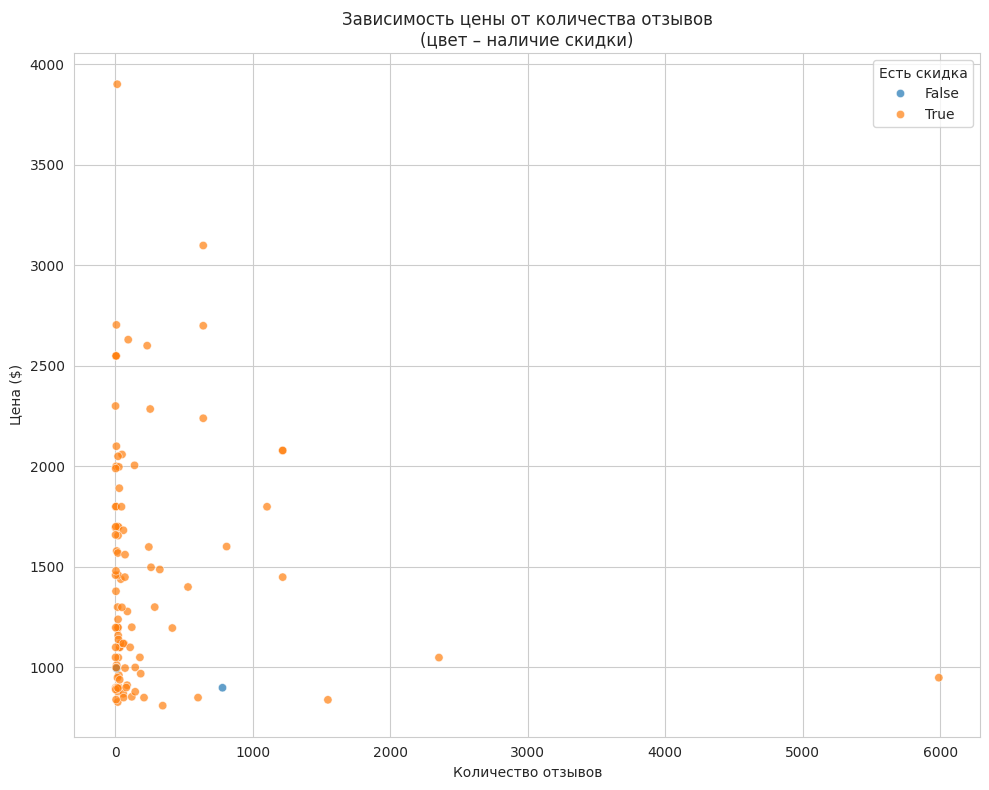

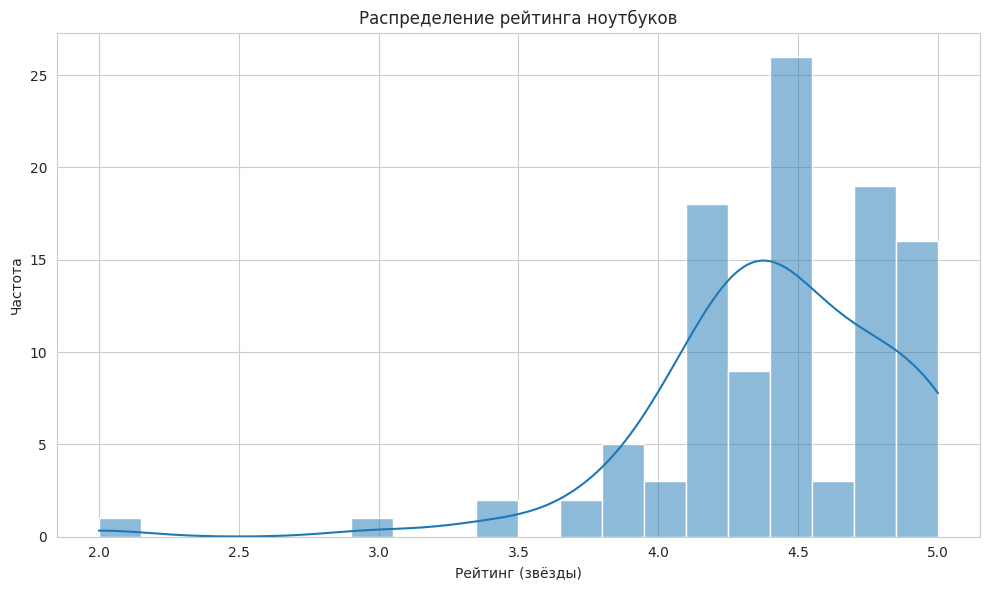

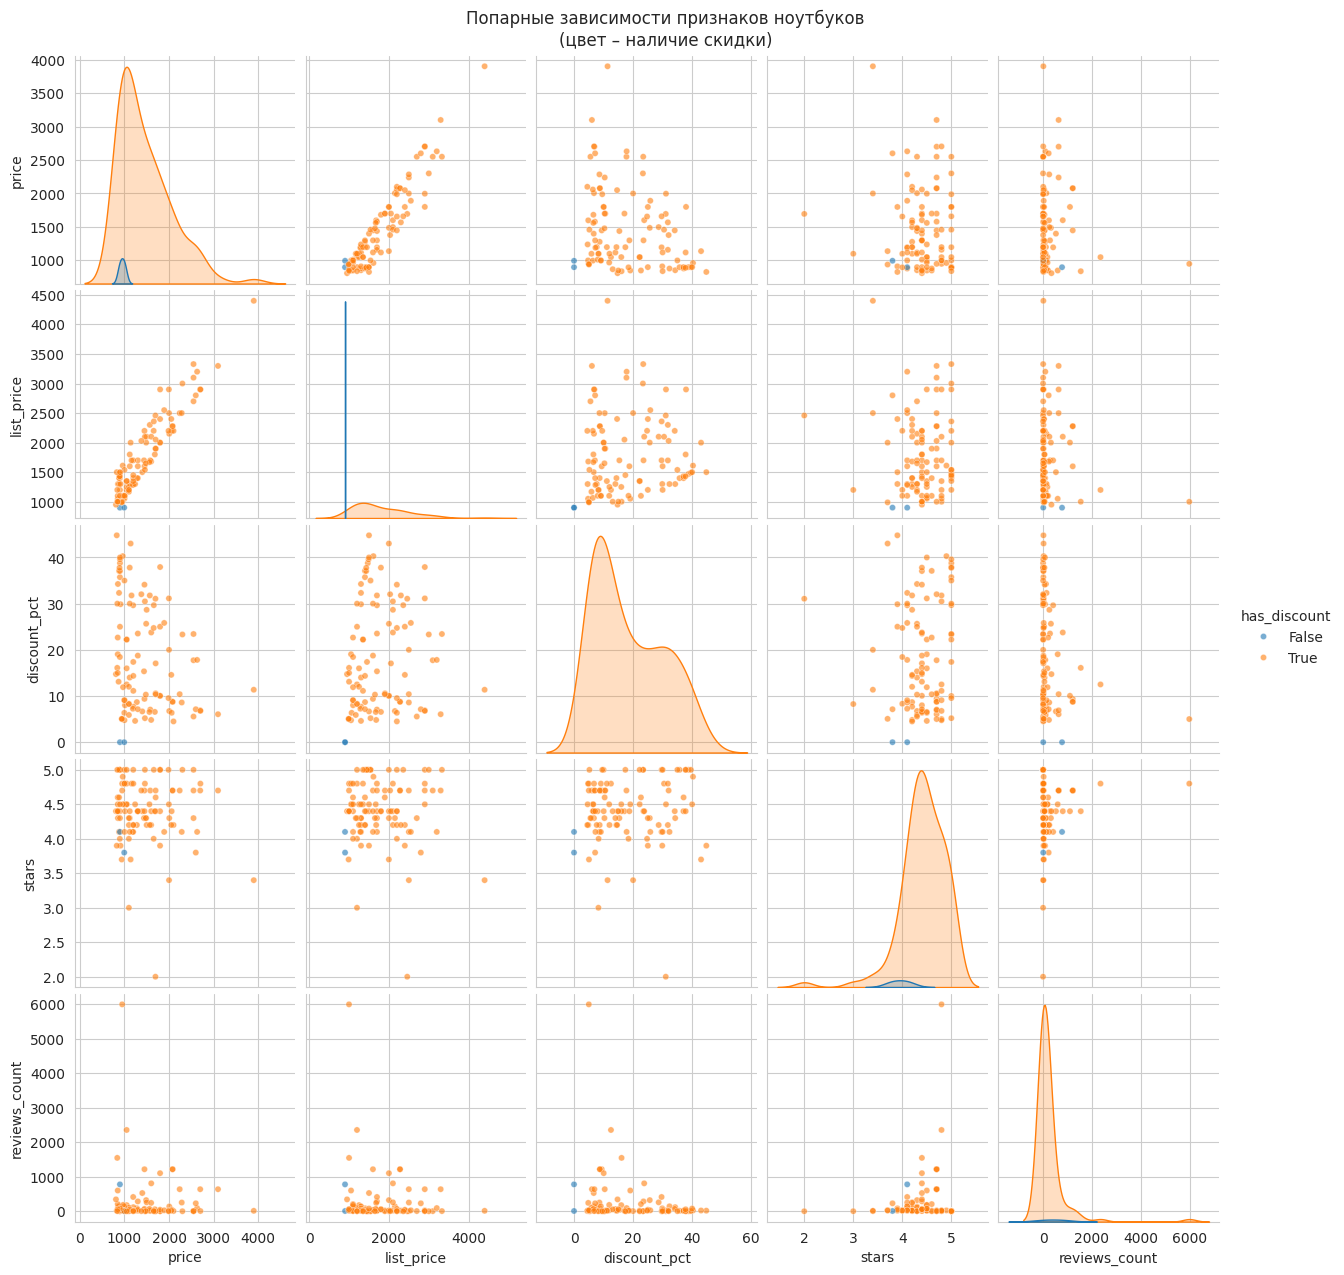

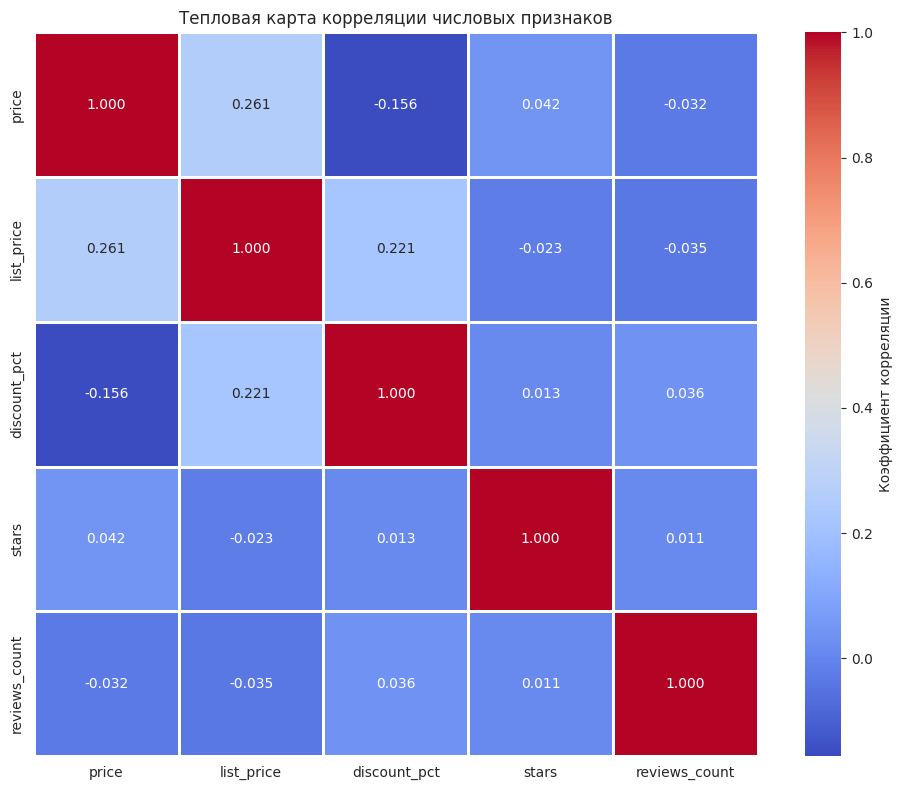

In [13]:
# оздадим признак наличия скидки для группировки по цвету
df['has_discount'] = df['discount_pct'].fillna(0) > 0

# Удалим строки с пропусками в ключевых числовых столбцах для чистоты графиков
numeric_cols = ['price', 'list_price', 'discount_pct', 'stars', 'reviews_count']
df_clean = df.dropna(subset=numeric_cols).copy()

# 1. Scatterplot с группировкой по цвету (hue)
#    Зависимость цены от количества отзывов, окраска по наличию скидки
fig, ax = plt.subplots(figsize=(10,8))
sns.scatterplot(ax=ax, x='reviews_count', y='price', data=df_clean, hue='has_discount', alpha=0.7)
ax.set_title('Зависимость цены от количества отзывов\n(цвет – наличие скидки)')
ax.set_xlabel('Количество отзывов')
ax.set_ylabel('Цена ($)')
plt.legend(title='Есть скидка')
plt.tight_layout()
plt.show()

# 2. Гистограмма (distplot) – распределение рейтинга (stars)
#    Используем histplot + kde (современная замена distplot)

fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(df_clean['stars'], kde=True, bins=20, ax=ax)
ax.set_title('Распределение рейтинга ноутбуков')
ax.set_xlabel('Рейтинг (звёзды)')
ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

# 3. Pairplot – попарные зависимости нескольких признаков
#    Выбираем числовые признаки, группируем по наличию скидки
# Для pairplot возьмём ограниченный набор признаков, чтобы график был читаемым
selected_features = ['price', 'list_price', 'discount_pct', 'stars', 'reviews_count']
# Удалим строки с пропусками в этих столбцах
df_pair = df.dropna(subset=selected_features + ['has_discount']).copy()

# чутка ограничим количество точек для ускорения (если у нас ну очень много данных)
if len(df_pair) > 1000:
    df_pair = df_pair.sample(n=1000, random_state=42)

g = sns.pairplot(df_pair, vars=selected_features, hue='has_discount', diag_kind='kde',
                 plot_kws={'alpha':0.6, 's':20})
g.fig.suptitle('Попарные зависимости признаков ноутбуков\n(цвет – наличие скидки)', y=1.02)
plt.show()

# 4. Тепловая карта корреляции (heatmap) с аннотациями
# Вычислим корреляцию для всех числовых столбцов, заполнив пропуски медианой
df_corr = df[numeric_cols].copy().fillna(df[numeric_cols].median())
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=1, square=True, cbar_kws={'label': 'Коэффициент корреляции'})
ax.set_title('Тепловая карта корреляции числовых признаков')
plt.tight_layout()
plt.show()